<a href="https://colab.research.google.com/github/dev-anju/ParkZen/blob/main/parkZen_after_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
dataset_path = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"

In [3]:
import os

print(os.path.exists("/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"))

True


In [4]:
import os

dataset_path = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"

for split in ["train", "valid", "test"]:
    image_path = os.path.join(dataset_path, split, "images")
    label_path = os.path.join(dataset_path, split, "labels")

    images = os.listdir(image_path)
    labels = os.listdir(label_path)

    print(f"\n{split.upper()}")
    print("Images :", len(images))
    print("Labels :", len(labels))


TRAIN
Images : 8653
Labels : 8653

VALID
Images : 2483
Labels : 2483

TEST
Images : 1242
Labels : 1242


In [5]:
import os

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "valid", "test"]:

    image_dir = os.path.join(dataset_path, split, "images")
    label_dir = os.path.join(dataset_path, split, "labels")

    image_names = {
        os.path.splitext(f)[0]
        for f in os.listdir(image_dir)
        if os.path.splitext(f)[1].lower() in image_extensions
    }

    label_names = {
        os.path.splitext(f)[0]
        for f in os.listdir(label_dir)
        if f.endswith(".txt")
    }

    missing_labels = image_names - label_names
    missing_images = label_names - image_names

    print("\n", split.upper())

    print("Images:", len(image_names))
    print("Labels:", len(label_names))

    print("Images without labels:", len(missing_labels))
    print("Labels without images:", len(missing_images))


 TRAIN
Images: 8653
Labels: 8653
Images without labels: 0
Labels without images: 0

 VALID
Images: 2483
Labels: 2483
Images without labels: 0
Labels without images: 0

 TEST
Images: 1242
Labels: 1242
Images without labels: 0
Labels without images: 0


In [6]:
import os

for split in ["train", "valid", "test"]:

    label_dir = os.path.join(dataset_path, split, "labels")

    invalid_files = []
    invalid_lines = 0

    for filename in os.listdir(label_dir):

        if not filename.endswith(".txt"):
            continue

        filepath = os.path.join(label_dir, filename)

        with open(filepath, "r") as f:
            lines = f.readlines()

        for line_number, line in enumerate(lines, start=1):

            line = line.strip()

            if not line:
                continue

            parts = line.split()

            # YOLO format must have 5 values
            if len(parts) != 5:
                invalid_files.append(filename)
                invalid_lines += 1
                continue

            try:
                class_id = int(parts[0])
                x, y, w, h = map(float, parts[1:])
            except:
                invalid_files.append(filename)
                invalid_lines += 1
                continue

            # Class must be 0 or 1
            if class_id not in [0, 1]:
                invalid_files.append(filename)
                invalid_lines += 1
                continue

            # Coordinates must be between 0 and 1
            if not (0 <= x <= 1 and
                    0 <= y <= 1 and
                    0 < w <= 1 and
                    0 < h <= 1):

                invalid_files.append(filename)
                invalid_lines += 1

    print(f"\n{split.upper()}")
    print("Invalid files :", len(set(invalid_files)))
    print("Invalid lines :", invalid_lines)


TRAIN
Invalid files : 0
Invalid lines : 0

VALID
Invalid files : 0
Invalid lines : 0

TEST
Invalid files : 0
Invalid lines : 0


In [7]:
from collections import Counter
import os

for split in ["train", "valid", "test"]:

    label_dir = os.path.join(dataset_path, split, "labels")

    counter = Counter()

    for filename in os.listdir(label_dir):

        if not filename.endswith(".txt"):
            continue

        filepath = os.path.join(label_dir, filename)

        with open(filepath, "r") as f:
            for line in f:

                line = line.strip()

                if not line:
                    continue

                class_id = int(line.split()[0])
                counter[class_id] += 1

    print(f"\n{split.upper()}")
    print("Empty spaces   :", counter[0])
    print("Occupied spaces:", counter[1])


TRAIN
Empty spaces   : 263452
Occupied spaces: 231904

VALID
Empty spaces   : 73629
Occupied spaces: 69687

TEST
Empty spaces   : 36584
Occupied spaces: 34100


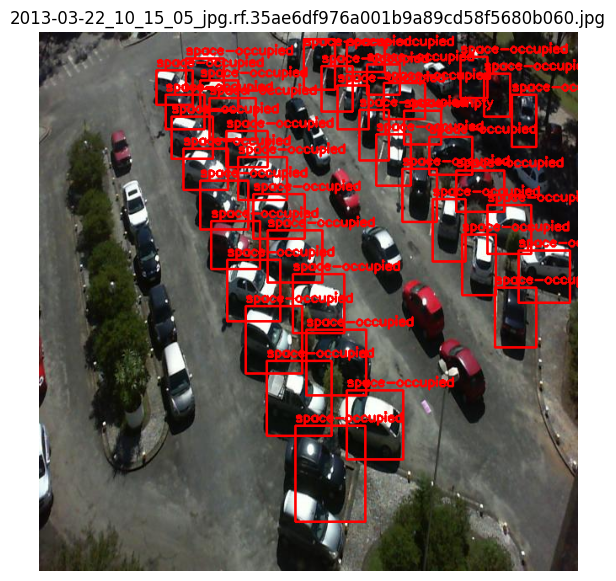

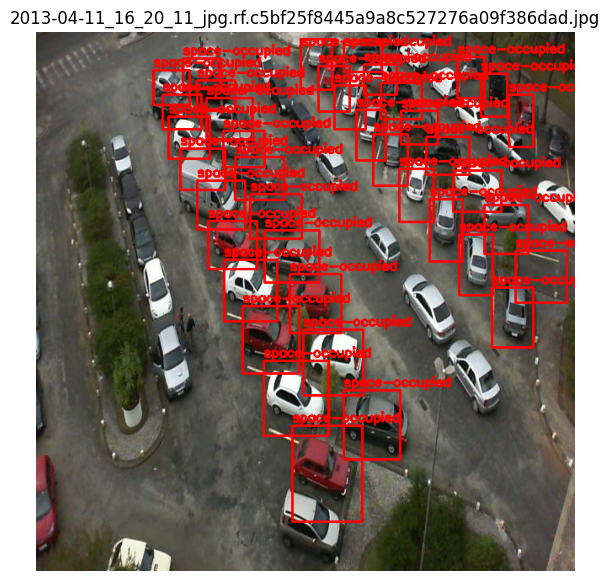

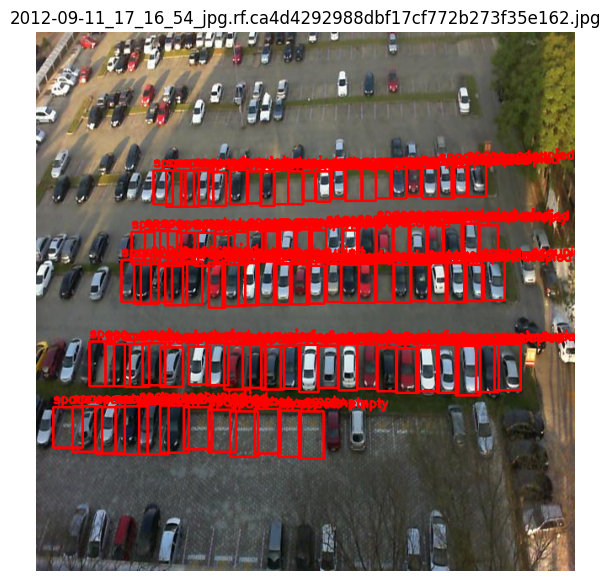

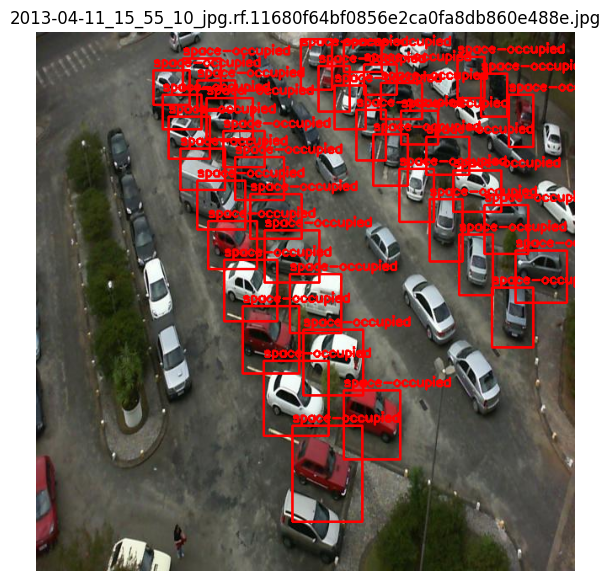

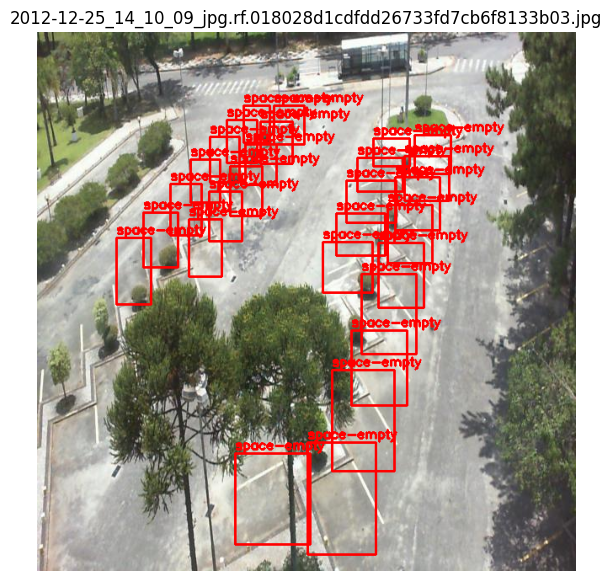

In [8]:
import os
import random
import cv2
import matplotlib.pyplot as plt

image_dir = os.path.join(dataset_path, "train", "images")
label_dir = os.path.join(dataset_path, "train", "labels")

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random_images = random.sample(image_files, 5)

class_names = {
    0: "space-empty",
    1: "space-occupied"
}

for image_file in random_images:

    image_path = os.path.join(image_dir, image_file)
    label_path = os.path.join(
        label_dir,
        os.path.splitext(image_file)[0] + ".txt"
    )

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w, _ = image.shape

    if os.path.exists(label_path):

        with open(label_path, "r") as f:

            for line in f:

                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                class_id = int(parts[0])
                x_center, y_center, box_w, box_h = map(float, parts[1:])

                x1 = int((x_center - box_w / 2) * w)
                y1 = int((y_center - box_h / 2) * h)

                x2 = int((x_center + box_w / 2) * w)
                y2 = int((y_center + box_h / 2) * h)

                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (255, 0, 0),
                    2
                )

                cv2.putText(
                    image,
                    class_names[class_id],
                    (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255, 0, 0),
                    2
                )

    plt.figure(figsize=(10, 7))
    plt.imshow(image)
    plt.title(image_file)
    plt.axis("off")
    plt.show()

In [2]:
import os

base = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"

print("train exists:", os.path.exists(base + "/train"))
print("valid exists:", os.path.exists(base + "/valid"))
print("test exists :", os.path.exists(base + "/test"))
print("data.yaml exists:", os.path.exists(base + "/data.yaml"))

train exists: True
valid exists: True
test exists : True
data.yaml exists: True


In [5]:
import shutil
import os

source = "/content/drive/MyDrive/dataset"
destination = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"

# Copy test folder
shutil.copytree(
    os.path.join(source, "test"),
    os.path.join(destination, "test"),
    dirs_exist_ok=True
)

# Copy data.yaml
shutil.copy(
    os.path.join(source, "data.yaml"),
    os.path.join(destination, "data.yaml")
)

print("✅ test folder and data.yaml copied successfully!")

✅ test folder and data.yaml copied successfully!


In [ ]:
import os

base = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"

print("train exists:", os.path.exists(base + "/train"))
print("valid exists:", os.path.exists(base + "/valid"))
print("test exists :", os.path.exists(base + "/test"))
print("data.yaml exists:", os.path.exists(base + "/data.yaml"))

train exists: True
valid exists: True
test exists : True
data.yaml exists: True


In [ ]:
import shutil

shutil.make_archive(
    "/content/Cleaned_Dataset",    # ZIP file name
    "zip",                         # ZIP format
    "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"
)

print("✅ ZIP file created successfully!")

✅ ZIP file created successfully!


In [ ]:
from google.colab import files

files.download("/content/Cleaned_Dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import os

base = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"

for root, dirs, files in os.walk(base):
    print(root)
    print("Folders:", dirs)
    print("Files:", len(files))
    print("-"*50)

/content/drive/MyDrive/Parking_Project/Cleaned_Dataset
Folders: ['valid', 'train', 'test']
Files: 3
--------------------------------------------------
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/valid
Folders: ['images', 'labels']
Files: 1
--------------------------------------------------
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/valid/images
Folders: []
Files: 2483
--------------------------------------------------
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/valid/labels
Folders: []
Files: 2483
--------------------------------------------------
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/train
Folders: ['labels', 'images']
Files: 1
--------------------------------------------------
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/train/labels
Folders: []
Files: 8653
--------------------------------------------------
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/train/images
Folders: []
Files: 8653
--------------------------

In [ ]:
!find /content/drive/MyDrive -type d -name "test"
!find /content/drive/MyDrive -type d -name "valid"
!find /content/drive/MyDrive -type d -name "labels"

/content/drive/MyDrive/dataset/test
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test
/content/drive/MyDrive/dataset/valid
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/valid
/content/drive/MyDrive/dataset/valid/labels
/content/drive/MyDrive/dataset/train/labels
/content/drive/MyDrive/dataset/test/labels
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/valid/labels
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/train/labels
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/labels


In [ ]:
!find /content/drive/MyDrive -path "*valid/labels"

/content/drive/MyDrive/dataset/valid/labels
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/valid/labels


In [ ]:
import os

folders = {
    "dataset/train/images": "/content/drive/MyDrive/dataset/train/images",
    "dataset/train/labels": "/content/drive/MyDrive/dataset/train/labels",
    "dataset/valid/images": "/content/drive/MyDrive/dataset/valid/images",
    "dataset/valid/labels": "/content/drive/MyDrive/dataset/valid/labels",
    "dataset/test/images": "/content/drive/MyDrive/dataset/test/images",
    "dataset/test/labels": "/content/drive/MyDrive/dataset/test/labels",
}

for name, path in folders.items():
    if os.path.exists(path):
        print(f"{name}: {len(os.listdir(path))}")
    else:
        print(f"{name}: NOT FOUND")

dataset/train/images: 0
dataset/train/labels: 0
dataset/valid/images: 0
dataset/valid/labels: 0
dataset/test/images: 48
dataset/test/labels: 0


In [ ]:
!find /content/drive/MyDrive -type d -name "train"

/content/drive/MyDrive/dataset/train
/content/drive/MyDrive/dataset/runs/detect/train
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/train


In [ ]:
!find /content/drive/MyDrive -type d -name "images"

/content/drive/MyDrive/dataset/valid/images
/content/drive/MyDrive/dataset/train/images
/content/drive/MyDrive/dataset/test/images
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/valid/images
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/train/images
/content/drive/MyDrive/Parking_Project/Cleaned_Dataset/test/images


In [10]:
import os

base = "/content/drive/MyDrive/Parking_Project/Cleaned_Dataset"

for split in ["train", "valid", "test"]:
    img = os.path.join(base, split, "images")
    lbl = os.path.join(base, split, "labels")

    print(f"\n{split.upper()}")
    print("Images:", len(os.listdir(img)) if os.path.exists(img) else "Missing")
    print("Labels:", len(os.listdir(lbl)) if os.path.exists(lbl) else "Missing")


TRAIN
Images: 8653
Labels: 8653

VALID
Images: 2483
Labels: 2483

TEST
Images: 1242
Labels: 1242


In [ ]:
import os

base = "/content/Cleaned_Dataset"

for split in ["train", "valid", "test"]:
    print(f"\n{split.upper()}")
    print("Images:", len(os.listdir(os.path.join(base, split, "images"))))
    print("Labels:", len(os.listdir(os.path.join(base, split, "labels"))))


TRAIN


FileNotFoundError: [Errno 2] No such file or directory: '/content/Cleaned_Dataset/train/images'

In [11]:
!ls /content

drive  sample_data
